**Task II: Classical Graph Neural Network (GNN)**

For Task II, you will use ParticleNet’s data for Quark/Gluon jet classification available here with its corresponding description. 

● Choose 2 Graph-based architectures of your choice to classify jets as being quarks or gluons. Provide a description on what considerations you have taken to project this point-cloud dataset to a set of interconnected nodes and edges. 

● Discuss the resulting performance of the 2 chosen architectures. 


In [1]:
!pip install torch torch-geometric energyflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.2/502.2 kB 24.6 MB/s eta 0:00:00


In [2]:
!pip install torch_scatter torch_sparse torch_spline_conv -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install torch_cluster -f https://data.pyg.org/whl/torch-2.5.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 31.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 991.6/991.6 kB 2.6 MB/s eta 0:00:00a 0:00:010m
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 31.0 MB/s eta 0:00:0000:0100:01


In [41]:
import energyflow as ef 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import EdgeConv, GCNConv, GATConv, global_mean_pool
from scipy.spatial import distance_matrix
from torch_cluster import knn_graph
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
from torch_geometric.nn import Sequential as gnnSequential
from torch.utils.data import random_split
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import energyflow
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load dataset
num_jets = 100000
X, y = ef.qg_jets.load(num_data=num_jets, pad=True, ncol=4, generator='pythia')

In [5]:
X = X[:,:,:3] # using only the features pt,rapidity,azimuthal angle

# Parallel Hybrid GCN + GAT architecture:
This is one custom architecture that I have come up with. GCN(Graph Convolution Network) comprises of CNN like layers for graph structured data and similarly GAT(Graph Attention Network) comprises of attention modules. In this custom architecture, I have tried to extract features from the raw graph data using both GCN and GAT and concatenated those features to apply one layer of GAT to capture interdependencies.

In [42]:
class ParallelHybridGraphModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super(ParallelHybridGraphModel, self).__init__()

        # GCN Branch
        self.gcn1 = GCNConv(in_channels, hidden_channels)
        self.gcn2 = GCNConv(hidden_channels, hidden_channels)

        # GAT Branch
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, concat=False)
        self.gat2 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=False)

        # Final GAT layer after concatenation
        self.final_gat = GATConv(hidden_channels * 2, hidden_channels, heads=1, concat=False)

        # Fully connected classification layer
        self.fc = nn.Linear(hidden_channels, out_channels)

    def forward(self, data):
        # GCN Branch
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x_gcn = F.relu(self.gcn1(x, edge_index))
        x_gcn = F.relu(self.gcn2(x_gcn, edge_index))

        # GAT Branch
        x_gat = F.elu(self.gat1(x, edge_index))
        x_gat = F.elu(self.gat2(x_gat, edge_index))

        # Concatenate the outputs
        x_combined = torch.cat([x_gcn, x_gat], dim=1)

        # Final GAT for refining
        x_out = F.elu(self.final_gat(x_combined, edge_index))

        # Global mean pooling to get graph-level features
        x_pooled = global_mean_pool(x_out, batch)

        # Classification
        x_final = self.fc(x_pooled)
        return x_final


In [43]:
model = ParallelHybridGraphModel(3, 64, 2).to(device)
print(model)

ParallelHybridGraphModel(
  (gcn1): GCNConv(3, 64)
  (gcn2): GCNConv(64, 64)
  (gat1): GATConv(3, 64, heads=4)
  (gat2): GATConv(64, 64, heads=4)
  (final_gat): GATConv(128, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


In [40]:
k = 5  # Number of neighbors

dataset = []
for i in range(num_jets):
    mask = np.where(X[i, :, 0] > 0)
    num_nodes = len(mask[0])
    if num_nodes <= 1: # neglecting graphs with less than or equal to 1 node
        continue

    node_features = torch.tensor(X[i, mask, :].squeeze(), dtype=torch.float)
    labels = torch.tensor(y[i], dtype=torch.long)

    # Generate KNN graph
    edge_index = knn_graph(node_features, k=k, loop=False)

    dataset.append(Data(
        x=node_features,
        y=labels,
        edge_index=edge_index,
        num_nodes=num_nodes
    ))

In [44]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_data, val_data = random_split(dataset, [train_size, val_size])

# DataLoader
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
print(f"Created {len(dataset)} graphs, ready for training!")

/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Created 99998 graphs, ready for training!


In [45]:
# 🔧 Training Setup
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Training Loop
def train():
    model.train()
    n_iter = len(train_loader)
    tq = tqdm.tqdm(enumerate(train_loader),total=n_iter)
    total_loss = 0
    all_preds, all_labels = [], []
    for i, data in tq:
        optimizer.zero_grad()
        inputs = data 
        labels = data.y
        inputs = inputs.to(device)
        labels = labels.to(device)
        output = model(inputs)
        loss = criterion(output, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()
        preds = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    scheduler.step()
    acc = accuracy_score(all_labels, all_preds)
    return acc, total_loss/len(train_loader)  # Cost per example

# Validation Loop
def evaluate():
    model.eval()
    n_iter = len(val_loader)
    tq = tqdm.tqdm(enumerate(val_loader),total=n_iter)
    all_preds, all_pred_labels, all_labels = [], [], []
    with torch.no_grad():
        for i, data in tq:
            inputs = data 
            labels = data.y
            inputs = inputs.to(device)
            labels = labels.to(device)
            output = model(inputs)
            # preds = output.argmax(dim=1).cpu().numpy()
            preds = F.softmax(model(inputs.to(device)), dim=1).cpu().detach().numpy()
            all_preds.extend(preds[:,1])
            all_pred_labels.extend(output.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_pred_labels)
    roc_auc = roc_auc_score(all_labels, all_preds)
    return acc, roc_auc

# Train Model
for epoch in range(25):
    train_acc, train_loss = train()
    val_acc, val_roc = evaluate()
    print(f"Epoch {epoch+1}: Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}, Val ROC-AUC = {val_roc:.4f}")


100%|██████████| 313/313 [00:04<00:00, 74.33it/s]


Epoch 1: Loss = 0.5172, Train Acc = 0.7523, Val Acc = 0.7634, Val ROC-AUC = 0.8386


100%|██████████| 313/313 [00:04<00:00, 73.41it/s]


Epoch 2: Loss = 0.5048, Train Acc = 0.7637, Val Acc = 0.7661, Val ROC-AUC = 0.8424


100%|██████████| 313/313 [00:04<00:00, 74.20it/s]


...

Epoch 23: Loss = 0.4915, Train Acc = 0.7710, Val Acc = 0.7714, Val ROC-AUC = 0.8459


100%|██████████| 313/313 [00:04<00:00, 75.80it/s]


Epoch 24: Loss = 0.4913, Train Acc = 0.7707, Val Acc = 0.7719, Val ROC-AUC = 0.8457


100%|██████████| 313/313 [00:04<00:00, 75.45it/s]

Epoch 25: Loss = 0.4908, Train Acc = 0.7706, Val Acc = 0.7707, Val ROC-AUC = 0.8458


In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_auc(y_true, y_scores, num_classes=2):
    plt.figure(figsize=(10, 8))

    # For binary classification
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    else:
        # For multi-class classification (One-vs-Rest)
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    # Plot random chance
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


def evaluate_and_plot_roc_auc(model, val_loader, device, num_classes=2):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data in val_loader:
            labels = data.y
            labels = labels.to(device)
            data = data.to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Plot ROC Curve
    plot_roc_auc(all_labels, all_probs, num_classes=num_classes)


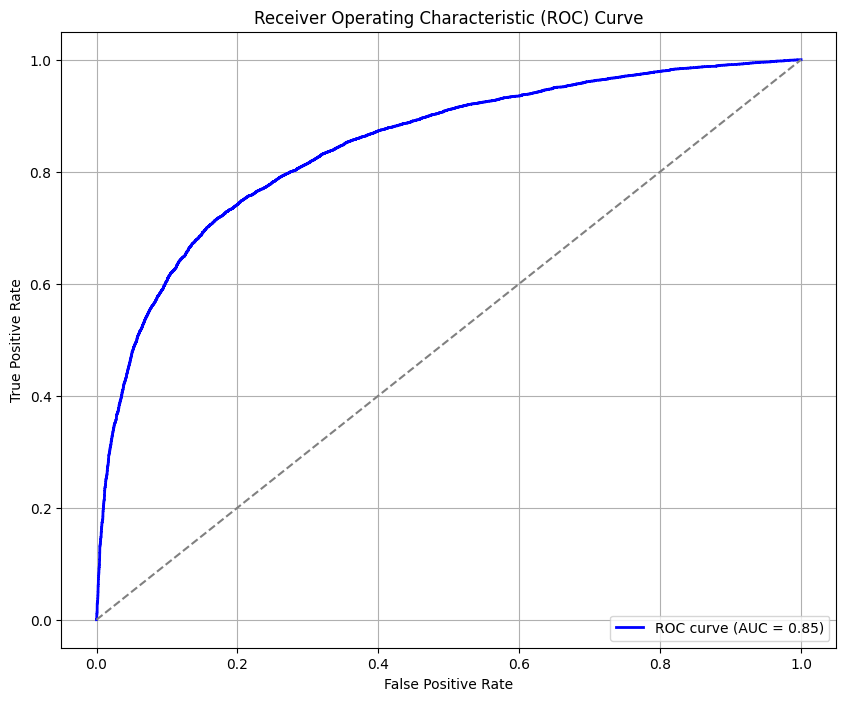

In [51]:
evaluate_and_plot_roc_auc(model, val_loader, device)

**Analysing the results**

This custom model achieved really good results considering no extensive search for the optimal architecture. It achives training loss of 0.49, validation accuracy of 0.77 and validation roc-auc of close to 0.85 only after 25 epochs.

# ParticleNet ( With Dynamic GCN )
The second model that I've chosen is ParticleNet ([ref.](https://arxiv.org/pdf/1902.08570)). ParticleNet treats jet as particle cloud, meaning it ensures the respresentation is permutation-invariant as order of particles in this data has no significance. Particle clouds naturally capture the spatial and momentum relationships between particles. It is build upon EdgeConv which dynamically build graphs using k-nearest neighbors (KNN) at every layer. I've tried to make the architecture as close to as given in the original paper.

In [54]:
class EdgeConvBlock(nn.Module):
    def __init__(self, inp_size, hidden_dim):
        super(EdgeConvBlock, self).__init__()

        self.inp_size = inp_size
        self.hidden_dim = hidden_dim
        lyrs = []

        #first layer
        lyrs.append(nn.Linear(inp_size * 2, self.hidden_dim))
        lyrs.append(nn.BatchNorm1d(self.hidden_dim))
        lyrs.append(nn.ReLU())

        #second layer
        lyrs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        lyrs.append(nn.BatchNorm1d(self.hidden_dim))
        lyrs.append(nn.ReLU())

        #third layer
        lyrs.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        lyrs.append(nn.BatchNorm1d(self.hidden_dim))
        lyrs.append(nn.ReLU())

        self.model = nn.Sequential(*lyrs)

    def forward(self, x):
        return self.model(x)

In [55]:
class ParticleNet(nn.Module):
    def __init__(self, kernel_arch = [64, 128, 256], fc_arch = [256, 2], k=16):
        super(ParticleNet, self).__init__()

        self.k = k #for kNN algo
        self.kernel_arch = kernel_arch
        self.fc_arch = fc_arch

        self.kernel_arch.insert(0, 3)
        self.output_sizes = np.cumsum(self.kernel_arch)
        
        self.edge_convs = nn.ModuleList()
        self.edge_convs.append(EdgeConv(EdgeConvBlock(3,self.kernel_arch[1]), aggr="mean"))
        for i in range(1, len(self.kernel_arch)-1):
            self.edge_convs.append(EdgeConv(EdgeConvBlock(self.output_sizes[i],self.kernel_arch[i+1]), aggr="mean"))

        self.fc1 = nn.Sequential(nn.Linear(self.output_sizes[-1], self.fc_arch[0]))
        self.dropout = nn.Dropout(p=0.1)
        self.fc2 = nn.Linear(self.fc_arch[0], self.fc_arch[1])
        
    def forward(self, data):
        # input data
        x = data.x
        batch = data.batch

        for i in range(len(self.edge_convs)):
            edge_index = (
                knn_graph(x[:, :2], self.k, batch) if i == 0 else knn_graph(x, self.k, batch)
            )
            x = torch.cat(
                (self.edge_convs[i](x, edge_index), x), dim=1
            ) # i.e. skip connection

        x = global_mean_pool(x, batch)
        x = self.dropout(self.fc1(x))

        return self.fc2(x)

In [53]:
train_size = int(0.8 * len(dataset2))
val_size = len(dataset2) - train_size
train_data, val_data = random_split(dataset2, [train_size, val_size])

# DataLoader
train_loader2 = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader2 = DataLoader(val_data, batch_size=64, shuffle=False)
print(f"Created {len(dataset2)} graphs, ready for training!")

Created 99998 graphs, ready for training!


/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [52]:
# X = X_transform
num_jets = len(X)
dataset2 = []

for i in range(num_jets):
    mask = np.where(X[i, :, 0] > 0)
    num_nodes = len(mask[0])
    if(num_nodes<=1): 
        continue
    dataset2.append(Data(
        x=torch.tensor(X[i, mask, :].squeeze(), dtype=torch.float),
        y=torch.tensor(y[i], dtype=torch.long),
        num_nodes=num_nodes
    ))

In [56]:
kernel_arch = [64, 128, 256] # The original ParticleNet Architecture
fc_arch = [256, 2]
model2 = ParticleNet(kernel_arch, fc_arch, 16).to(device)
print(model2)

ParticleNet(
  (edge_convs): ModuleList(
    (0): EdgeConv(nn=EdgeConvBlock(
      (model): Sequential(
        (0): Linear(in_features=6, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=64, out_features=64, bias=True)
        (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=64, bias=True)
        (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU()
      )
    ))
    (1): EdgeConv(nn=EdgeConvBlock(
      (model): Sequential(
        (0): Linear(in_features=134, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): BatchNorm1d(128, eps=1e-05, m

In [58]:
# 🔧 Training Setup
optimizer = optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Training Loop
def train():
    model2.train()
    n_iter = len(train_loader2)
    tq = tqdm.tqdm(enumerate(train_loader2),total=n_iter)
    total_loss = 0
    all_preds, all_labels = [], []
    for i, data in tq:
        optimizer.zero_grad()
        inputs = data 
        labels = data.y
        inputs = inputs.to(device)
        labels = labels.to(device)
        output = model2(inputs)
        loss = criterion(output, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()
        preds = output.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    scheduler.step()
    acc = accuracy_score(all_labels, all_preds)
    return acc, total_loss/len(train_loader2)  # Cost per example

# Validation Loop
def evaluate():
    model2.eval()
    n_iter = len(val_loader2)
    tq = tqdm.tqdm(enumerate(val_loader2),total=n_iter)
    all_preds, all_pred_labels, all_labels = [], [], []
    with torch.no_grad():
        for i, data in tq:
            inputs = data 
            labels = data.y
            inputs = inputs.to(device)
            labels = labels.to(device)
            output = model2(inputs)
            # preds = output.argmax(dim=1).cpu().numpy()
            preds = F.softmax(model2(inputs.to(device)), dim=1).cpu().detach().numpy()
            all_preds.extend(preds[:,1])
            all_pred_labels.extend(output.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_pred_labels)
    roc_auc = roc_auc_score(all_labels, all_preds)
    return acc, roc_auc

# Train Model
for epoch in range(20):
    train_acc, train_loss = train()
    val_acc, val_roc = evaluate()
    print(f"Epoch {epoch+1}: Loss = {train_loss:.4f}, Train Acc = {train_acc:.4f}, Val Acc = {val_acc:.4f}, Val ROC-AUC = {val_roc:.4f}")


100%|██████████| 313/313 [00:14<00:00, 21.97it/s]


Epoch 1: Loss = 0.4853, Train Acc = 0.7748, Val Acc = 0.7671, Val ROC-AUC = 0.8466


100%|██████████| 313/313 [00:14<00:00, 22.15it/s]


Epoch 2: Loss = 0.4854, Train Acc = 0.7745, Val Acc = 0.7730, Val ROC-AUC = 0.8472


100%|██████████| 313/313 [00:14<00:00, 22.20it/s]


...

Epoch 18: Loss = 0.4826, Train Acc = 0.7755, Val Acc = 0.7723, Val ROC-AUC = 0.8495


100%|██████████| 313/313 [00:14<00:00, 22.24it/s]


Epoch 19: Loss = 0.4819, Train Acc = 0.7764, Val Acc = 0.7665, Val ROC-AUC = 0.8487


100%|██████████| 313/313 [00:14<00:00, 22.24it/s]

Epoch 20: Loss = 0.4818, Train Acc = 0.7752, Val Acc = 0.7722, Val ROC-AUC = 0.8475


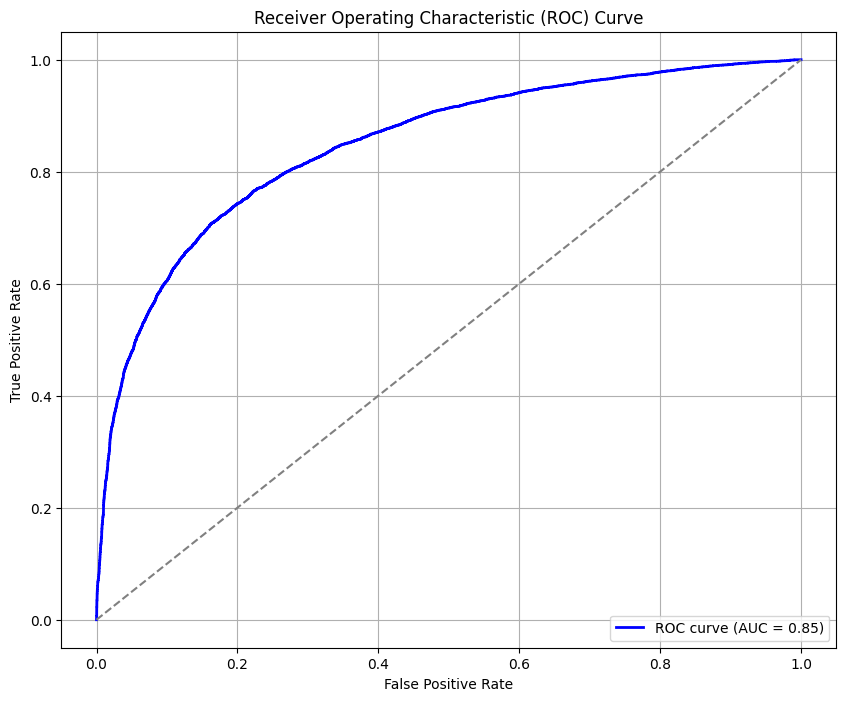

In [59]:
evaluate_and_plot_roc_auc(model2, val_loader2, device)